In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# Load dataset
df = pd.read_csv("dynamic_supply_chain_logistics_dataset.csv")

# Target column
target = "risk_classification"

X = df.drop(columns=[target])
y = df[target]

# Encode categorical features without creating thousands of columns
cat_cols = X.select_dtypes(include=['object']).columns

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X[cat_cols] = encoder.fit_transform(X[cat_cols])

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred, average="weighted"), 4),
        "Recall": round(recall_score(y_test, pred, average="weighted"), 4),
        "F1 Score": round(f1_score(y_test, pred, average="weighted"), 4)
    })

results = pd.DataFrame(results)
print(results.sort_values("Accuracy", ascending=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

                 Model  Accuracy  Precision  Recall  F1 Score
1        Decision Tree    1.0000     1.0000  1.0000    1.0000
2        Random Forest    1.0000     1.0000  1.0000    1.0000
3           Linear SVM    0.8438     0.7155  0.8438    0.7735
0  Logistic Regression    0.7468     0.5577  0.7468    0.6385
4                  KNN    0.7212     0.5920  0.7212    0.6365


In [ ]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision (%)": round(precision_score(y_test, y_pred, average="weighted") * 100, 2),
        "Recall (%)": round(recall_score(y_test, y_pred, average="weighted") * 100, 2),
        "F1 Score (%)": round(f1_score(y_test, y_pred, average="weighted") * 100, 2)
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values(by="Accuracy (%)", ascending=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

                 Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
1        Decision Tree        100.00         100.00      100.00        100.00
2        Random Forest        100.00         100.00      100.00        100.00
3           Linear SVM         84.38          71.55       84.38         77.35
0  Logistic Regression         74.68          55.77       74.68         63.85
4                  KNN         72.12          59.20       72.12         63.65


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=8),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ),
    "Linear SVM": LinearSVC(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
    )

    results.append({
        "Model": name,
        "Accuracy (%)": round(scores['test_accuracy'].mean() * 100, 2),
        "Precision (%)": round(scores['test_precision_weighted'].mean() * 100, 2),
        "Recall (%)": round(scores['test_recall_weighted'].mean() * 100, 2),
        "F1 Score (%)": round(scores['test_f1_weighted'].mean() * 100, 2)
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values(by="Accuracy (%)", ascending=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHE

                 Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
1        Decision Tree        100.00         100.00      100.00        100.00
2        Random Forest        100.00         100.00      100.00        100.00
3           Linear SVM         84.80          84.95       84.80         78.55
0  Logistic Regression         74.67          55.76       74.67         63.85
4                  KNN         72.17          59.51       72.17         63.79


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(20))

                            Feature  Importance
22      disruption_likelihood_score    0.935989
23                delay_probability    0.002894
13       supplier_reliability_score    0.002855
24          delivery_time_deviation    0.002847
9          order_fulfillment_status    0.002755
10       weather_condition_severity    0.002752
8   handling_equipment_availability    0.002748
14                   lead_time_days    0.002746
6         warehouse_inventory_level    0.002744
4               eta_variation_hours    0.002690
15                historical_demand    0.002674
1              vehicle_gps_latitude    0.002673
12                   shipping_costs    0.002668
11            port_congestion_level    0.002644
18                 route_risk_level    0.002638
21         fatigue_monitoring_score    0.002633
7            loading_unloading_time    0.002631
19           customs_clearance_time    0.002604
17           cargo_condition_status    0.002587
20            driver_behavior_score    0

In [ ]:
X = df.drop(columns=[
    "risk_classification",
    "disruption_likelihood_score",
    "delay_probability"
])

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision (%)": round(precision_score(y_test, y_pred, average="weighted") * 100, 2),
        "Recall (%)": round(recall_score(y_test, y_pred, average="weighted") * 100, 2),
        "F1 Score (%)": round(f1_score(y_test, y_pred, average="weighted") * 100, 2)
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values(by="Accuracy (%)", ascending=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

                 Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
1        Decision Tree        100.00         100.00      100.00        100.00
2        Random Forest        100.00         100.00      100.00        100.00
3           Linear SVM         84.38          71.55       84.38         77.35
0  Logistic Regression         74.68          55.77       74.68         63.85
4                  KNN         72.12          59.20       72.12         63.65


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a copy
X_temp = X.copy()

# Convert datetime columns to integer timestamps
for col in X_temp.columns:
    if "date" in col.lower() or "time" in col.lower():
        X_temp[col] = pd.to_datetime(X_temp[col]).astype("int64") // 10**9

# Encode all remaining object/string columns
for col in X_temp.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X_temp[col] = le.fit_transform(X_temp[col].astype(str))

# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_temp, y)

# Feature Importance
importance = pd.DataFrame({
    "Feature": X_temp.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

                            Feature  Importance
12                   shipping_costs    0.053578
1              vehicle_gps_latitude    0.053084
9          order_fulfillment_status    0.053050
5          traffic_congestion_level    0.052936
6         warehouse_inventory_level    0.052825
8   handling_equipment_availability    0.052690
10       weather_condition_severity    0.052641
21         fatigue_monitoring_score    0.052470
20            driver_behavior_score    0.052424
17           cargo_condition_status    0.052371
18                 route_risk_level    0.052322
0                         timestamp    0.052141
4               eta_variation_hours    0.052129
15                historical_demand    0.052084
2             vehicle_gps_longitude    0.052080
13       supplier_reliability_score    0.052054
11            port_congestion_level    0.051638
3             fuel_consumption_rate    0.051395
16                  iot_temperature    0.050864
22          delivery_time_deviation    0

In [ ]:
print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

Dataset Shape: (32065, 26)
Duplicate Rows: 0


In [ ]:
train_set = pd.DataFrame(X_train).astype(str).agg('-'.join, axis=1)
test_set = pd.DataFrame(X_test).astype(str).agg('-'.join, axis=1)

common = len(set(train_set).intersection(set(test_set)))
print("Common rows:", common)

Common rows: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=123,
    stratify=y
)

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
}

In [ ]:
print(df["risk_classification"].value_counts())

risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: int64


In [ ]:
print(df.shape)

(32065, 26)


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Convert timestamp column to datetime
X["timestamp"] = pd.to_datetime(X["timestamp"])

# Convert datetime to Unix timestamp (seconds)
X["timestamp"] = X["timestamp"].astype("int64") // 10**9

# Encode all remaining object columns
for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 74.68%


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name}: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Logistic Regression: 74.68%
Decision Tree: 57.24%
Random Forest: 74.68%
Linear SVM: 74.68%
KNN: 71.81%


In [ ]:
print(df["risk_classification"].value_counts())

risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: int64


In [ ]:
class_percent = (df["risk_classification"].value_counts(normalize=True) * 100).round(2)
print(class_percent)

risk_classification
High Risk        74.67
Moderate Risk    15.63
Low Risk          9.70
Name: proportion, dtype: float64


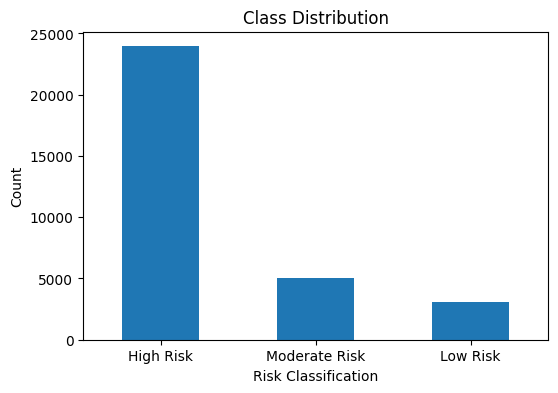

In [ ]:
import matplotlib.pyplot as plt

df["risk_classification"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Class Distribution"
)

plt.xlabel("Risk Classification")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred) * 100
    print(f"{name}: {accuracy:.2f}%")

Logistic Regression: 74.68%
Decision Tree: 57.24%
Random Forest: 74.68%
Linear SVM: 74.68%
KNN: 71.81%


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

results = []

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation
    accuracy = accuracy_score(y_test, y_pred) * 100
    precision = precision_score(y_test, y_pred, average='weighted') * 100
    recall = recall_score(y_test, y_pred, average='weighted') * 100
    f1 = f1_score(y_test, y_pred, average='weighted') * 100

    results.append([name, accuracy, precision, recall, f1])

    print("="*60)
    print(name)
    print("="*60)
    print("Accuracy : {:.2f}%".format(accuracy))
    print("Precision: {:.2f}%".format(precision))
    print("Recall   : {:.2f}%".format(recall))
    print("F1 Score : {:.2f}%".format(f1))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results,
                          columns=["Model","Accuracy (%)","Precision (%)","Recall (%)","F1 Score (%)"])

print(results_df.sort_values(by="Accuracy (%)",ascending=False))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Logistic Regression
Accuracy : 74.68%
Precision: 55.77%
Recall   : 74.68%
F1 Score : 63.85%

Confusion Matrix
[[4789    0    0]
 [ 622    0    0]
 [1002    0    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      4789
           1       0.00      0.00      0.00       622
           2       0.00      0.00      0.00      1002

    accuracy                           0.75      6413
   macro avg       0.25      0.33      0.29      6413
weighted avg       0.56      0.75      0.64      6413

Decision Tree
Accuracy : 57.24%
Precision: 58.99%
Recall   : 57.24%
F1 Score : 58.09%

Confusion Matrix
[[3425  524  840]
 [ 463   76   83]
 [ 718  114  170]]

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      4789
           1       0.11      0.12      0.11       622
           2       0.16      0.17      0.16      1002

    accuracy                   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Random Forest
Accuracy : 74.68%
Precision: 55.77%
Recall   : 74.68%
F1 Score : 63.85%

Confusion Matrix
[[4789    0    0]
 [ 622    0    0]
 [1002    0    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      4789
           1       0.00      0.00      0.00       622
           2       0.00      0.00      0.00      1002

    accuracy                           0.75      6413
   macro avg       0.25      0.33      0.29      6413
weighted avg       0.56      0.75      0.64      6413

Linear SVM
Accuracy : 74.68%
Precision: 55.77%
Recall   : 74.68%
F1 Score : 63.85%

Confusion Matrix
[[4789    0    0]
 [ 622    0    0]
 [1002    0    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      4789
           1       0.00      0.00      0.00       622
           2       0.00      0.00      0.00      1002

    accuracy                           0

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

param_grid = {
    'C':[0.01,0.1,1,10],
    'solver':['lbfgs','liblinear']
}

grid_lr = GridSearchCV(lr,param_grid,cv=5,scoring='accuracy',n_jobs=-1)

grid_lr.fit(X_train,y_train)

print("Best Parameters:",grid_lr.best_params_)
print("Best Accuracy:",grid_lr.best_score_*100)

Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best Accuracy: 74.67254083366669
